In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import drift
from scipy.optimize import minimize

# Load data

In [3]:
bead1 = xr.open_dataset('data/beads_horizontal_locations.nc').bead1
bead2 = xr.open_dataset('data/beads_horizontal_locations.nc').bead2
bead3 = xr.open_dataset('data/beads_vertical_locations.nc').bead1
bead4 = xr.open_dataset('data/beads_vertical_locations.nc').bead2

dt1 = float(bead1.t[1] - bead1.t[0]) # Inverse sampling rate for beads #1&2
tmsr1 = float(bead1.t[-1]) # Full measurement time for beads #1&2

dt3 = float(bead3.t[1] - bead3.t[0]) # Inverse sampling rate for beads #3&4
tmsr3 = float(bead3.t[-1]) # Full measurement time for beads #3&4

# Calculate periodograms

In [6]:
P1 = drift.periodogram(drift.detrend(bead1), dt1)[1:]
P3 = drift.periodogram(drift.detrend(bead3), dt3)[1:]

k1 = np.arange(1, len(P1) + 1)
k3 = np.arange(1, len(P3) + 1)

# Fit periodograms

In [28]:
# Fitting Bead #1
fit1 = minimize(drift.nll, 
                x0=np.array([0.1, 12.4])*1e-6, 
                args=(P1[2:3500], k1[2:3500], tmsr1), 
                jac=drift.nll_grad, 
                method='bfgs')

cov1 = drift.fisher_covariance(k1, *fit1.x, tmsr1)

D1, D1_std = fit1.x[0], np.sqrt(cov1[0, 0])
b1, b1_std = fit1.x[1], np.sqrt(cov1[1, 1])

# Fitting Bead #3
fit3 = minimize(drift.nll, 
                x0=np.array([0.421, 20.6])*1e-6, 
                args=(P3[3:700], k3[3:700], tmsr3), 
                jac=drift.nll_grad, 
                method='bfgs')

cov3 = drift.fisher_covariance(k3, *fit3.x, tmsr3)

D3, D3_std = fit3.x[0], np.sqrt(cov3[0, 0])
b3, b3_std = fit3.x[1], np.sqrt(cov3[1, 1])

# Print results
print('========== Bead #1 analysis results ==========')
print(f'D(bead #1) = {1e6*D1:.3f} +/- {1e6*D1_std:.3f} [nm^2/s]')
print(f'b(bead #1) = {1e6*b1:.1f} +/- {1e6*b1_std:.1f} [nm^2 s]')

print('========== Bead #3 analysis results ==========')
print(f'D(bead #3) = {1e6*D3:.3f} +/- {1e6*D3_std:.3f} [nm^2/s]')
print(f'b(bead #3) = {1e6*b3:.1f} +/- {1e6*b3_std:.1f} [nm^2 s]')

========== Bead #1 analysis results ==========
D(bead #1) = 0.199 +/- 0.021 [nm^2/s]
b(bead #1) = 13.9 +/- 0.2 [nm^2 s]
========== Bead #3 analysis results ==========
D(bead #3) = 0.415 +/- 0.062 [nm^2/s]
b(bead #3) = 32.5 +/- 1.1 [nm^2 s]


# Plot periodograms and their fits

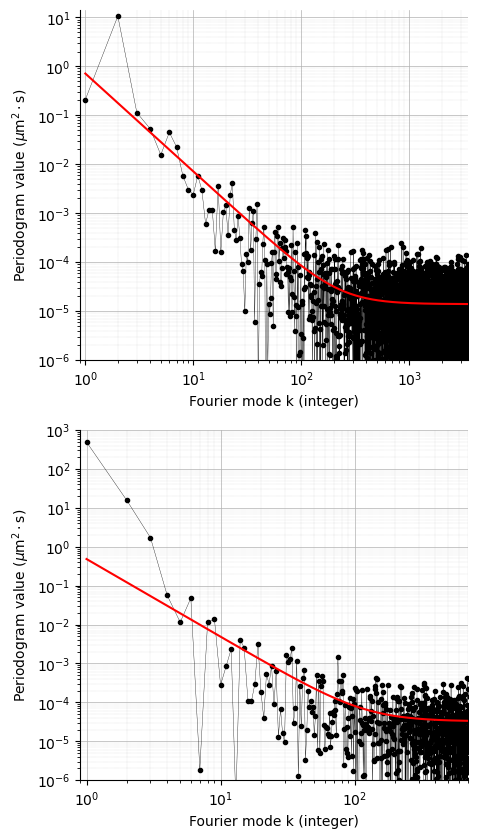

In [32]:
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(5, 10))

## Bead 1
ax1.loglog(k1, P1, c='k', marker='o', markersize=3, lw=0.25, rasterized=True)
ax1.loglog(k1, drift.spectrum(k1, *fit1.x, tmsr1), c='r')
ax1.set_xlim(0.9, 3500)
ax1.set_ylim(1e-6, 14)


## Bead 3
ax2.loglog(k3, P3, c='k', marker='o', markersize=3, lw=0.25, rasterized=True)
ax2.loglog(k3, drift.spectrum(k3, *fit3.x, tmsr3), c='r')
ax2.set_xlim(0.9, 700)
ax2.set_ylim(1e-6, 1e3)


for ax in [ax1, ax2]:
    
    ax.spines[['right', 'top']].set_visible(False)
    ax.grid(True, which='major', linestyle='-', linewidth=0.5)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.25)
    ax.set_ylabel(r'Periodogram value ($\mu$m$^2\cdot$s)')
    ax.set_xlabel(r'Fourier mode k (integer)')

# Plot block-averaged periodograms

In [31]:
P1_mean, P1_sem, k1_mean = drift.block_average_variable(P1[2:3500], 
                                             [4, 4, 4] + [16 for i in range(218)], 
                                             t=k1[2:3500])


P3_mean, P3_sem, k3_mean = drift.block_average_variable(P3[3:700], 
                                             [4, 4, 4, 4] + [16 for i in range(43)], 
                                             t=k3[3:700])

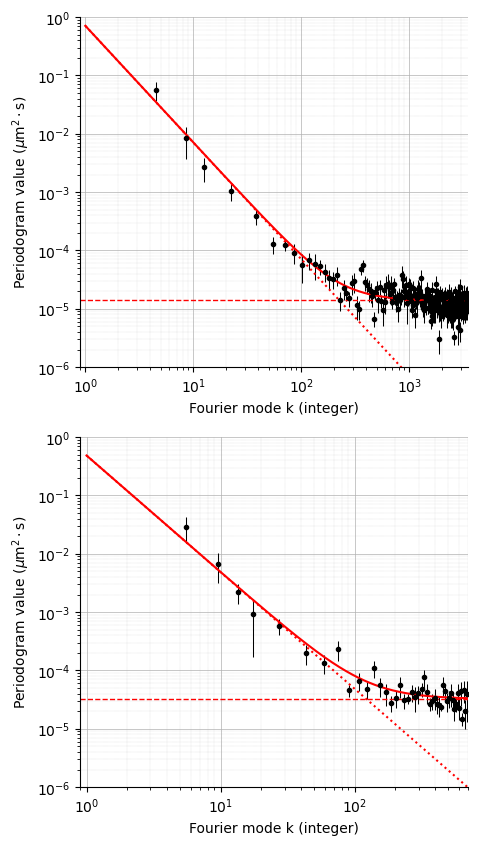

In [33]:
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(5, 10))

## Bead 1
ax1.errorbar(k1_mean, P1_mean, P1_sem, c='k', marker='o', markersize=3, ls='', rasterized=True, elinewidth=0.75)
ax1.plot(k1, drift.spectrum(k1, *fit1.x, tmsr1), c='r')
ax1.plot(k1, drift.spectrum(k1, fit1.x[0], 0, tmsr1), c='r', ls=':')
ax1.axhline(y=b1, ls='--', c='r', lw=1)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(0.9, 3500)
ax1.set_ylim(1e-6, 1)


## Bead 3
ax2.errorbar(k3_mean, P3_mean, P3_sem, c='k', marker='o', markersize=3, ls='', rasterized=True, elinewidth=0.75)
ax2.loglog(k3, drift.spectrum(k3, *fit3.x, tmsr3), c='r')
ax2.plot(k3, drift.spectrum(k3, fit3.x[0], 0, tmsr3), c='r', ls=':')
ax2.axhline(y=b3, ls='--', c='r', lw=1)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(0.9, 700)
ax2.set_ylim(1e-6, 1)


for ax in [ax1, ax2]:
    
    ax.spines[['right', 'top']].set_visible(False)
    ax.grid(True, which='major', linestyle='-', linewidth=0.5)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.25)
    ax.set_ylabel(r'Periodogram value ($\mu$m$^2\cdot$s)')
    ax.set_xlabel(r'Fourier mode k (integer)')